### Setup

In [ ]:
from ultralytics import YOLO
from ultralytics.data.split import autosplit

autosplit(
    path="dataset/images",
    weights=(0.8, 0.1, 0.1), # train, val, test split
)

model = YOLO("yolo11n.pt") # load pretrained model

Autosplitting images from dataset/images
: 100% ━━━━━━━━━━━━ 3000/3000 33.6Kit/s 0.1s


### Train

In [2]:
train_metrics = model.train(data="dataset/data.yaml", epochs=50, imgsz=224)

Ultralytics 8.4.40 🚀 Python-3.13.12 torch-2.11.0+cu130 CPU (Intel Core Ultra 7 265U)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-9, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

### Export to onnx

In [5]:
model.export(format="onnx", imgsz=224, opset=11, simplify=True)

Ultralytics 8.4.40 🚀 Python-3.13.12 torch-2.11.0+cu130 CPU (Intel Core Ultra 7 265U)

PyTorch: starting from '/home/bhed/Studium/pidgeon/model/runs/detect/train-9/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 5, 1029) (5.2 MB)

ONNX: starting export with onnx 1.21.0 opset 11...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 0.8s, saved as '/home/bhed/Studium/pidgeon/model/runs/detect/train-9/weights/best.onnx' (10.0 MB)

Export complete (0.9s)
Results saved to /home/bhed/Studium/pidgeon/model/runs/detect/train-9/weights
Predict:         yolo predict task=detect model=/home/bhed/Studium/pidgeon/model/runs/detect/train-9/weights/best.onnx imgsz=224 
Validate:        yolo val task=detect model=/home/bhed/Studium/pidgeon/model/runs/detect/train-9/weights/best.onnx imgsz=224 data=dataset/data.yaml  
Visualize:       https://netron.app


'/home/bhed/Studium/pidgeon/model/runs/detect/train-9/weights/best.onnx'

### Visualize predictions on test set

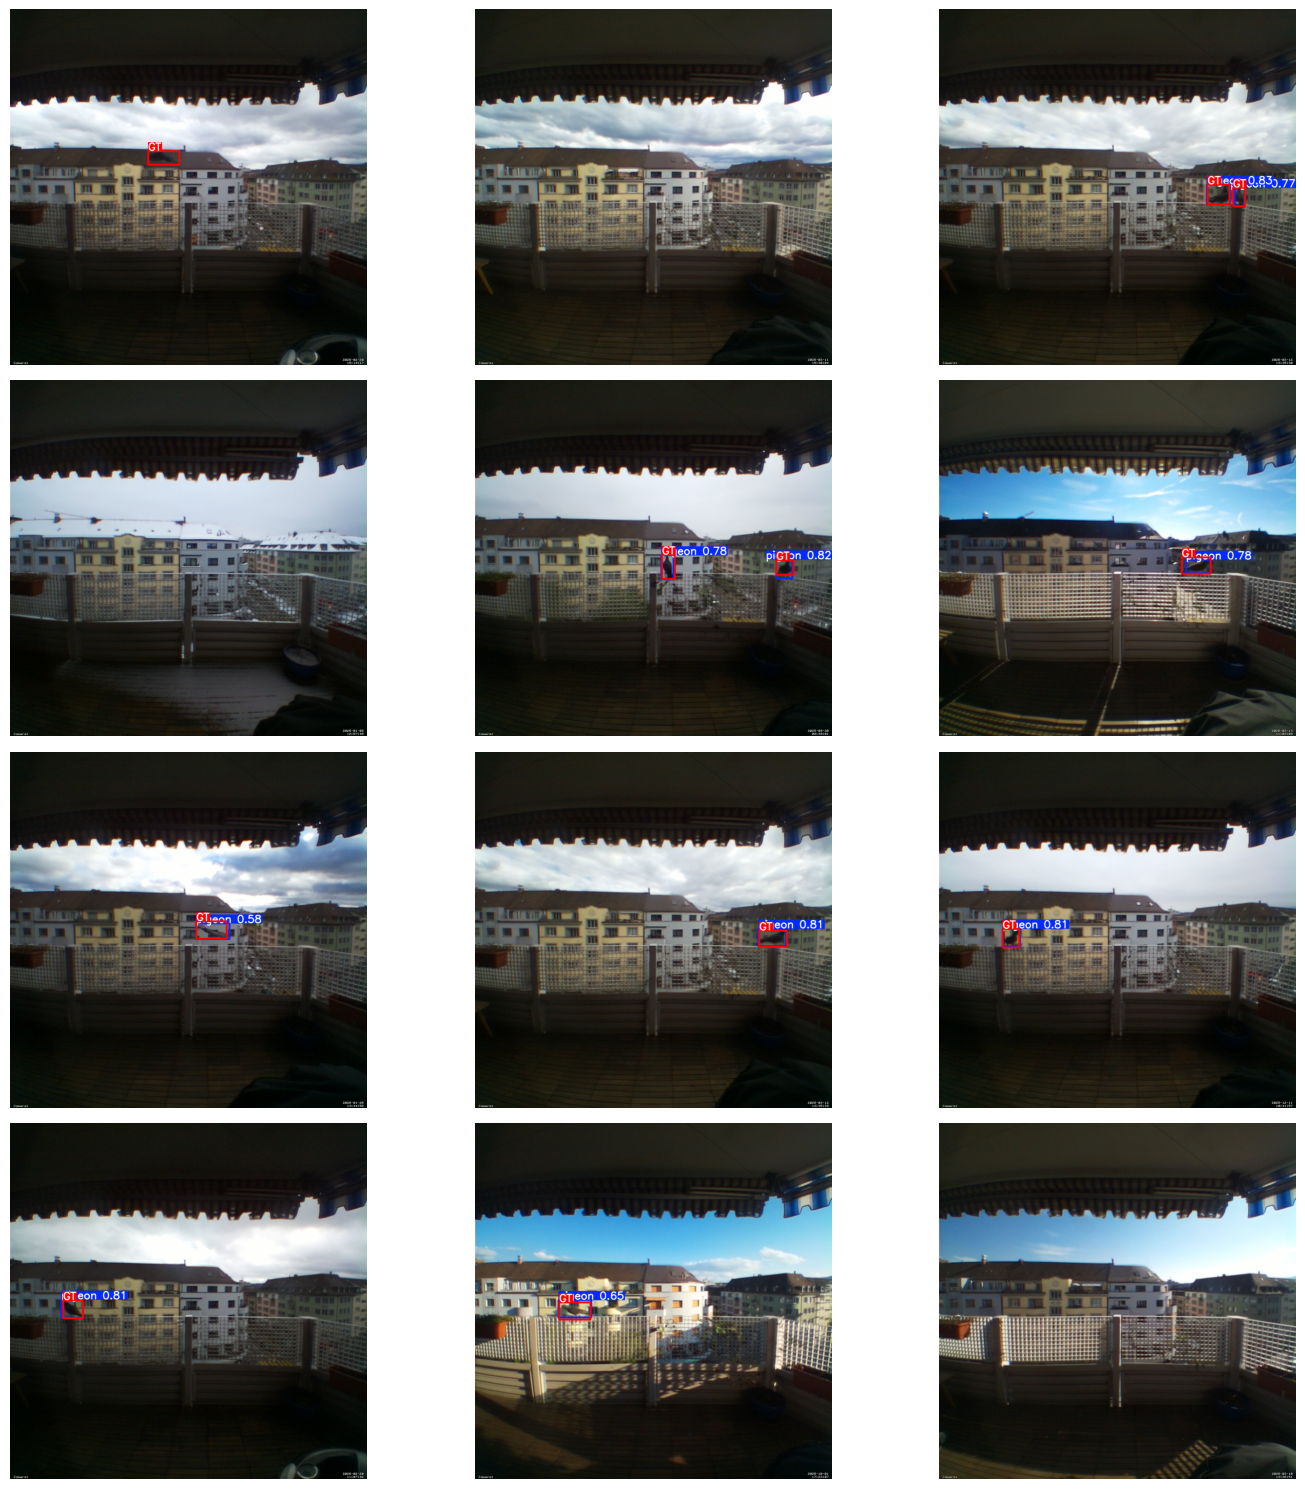

In [16]:
%matplotlib inline
import cv2
import random
import matplotlib.pyplot as plt
from ultralytics.utils.plotting import Annotator

val_paths = [
    "dataset/" + p.lstrip("./")
    for p in random.sample(open("dataset/autosplit_test.txt").read().strip().splitlines(), 12)
]

results = model(val_paths, verbose=False)

fig, axes = plt.subplots(4, 3, figsize=(15, 15))
for ax, r, img_path in zip(axes.flat, results, val_paths):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # Draw predictions
    annotator = Annotator(r.plot())

    # Draw ground truth (red) on top
    label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")
    for line in open(label_path):
        _, cx, cy, bw, bh = map(float, line.strip().split())
        x1, y1 = (cx - bw/2) * w, (cy - bh/2) * h
        x2, y2 = (cx + bw/2) * w, (cy + bh/2) * h
        annotator.box_label([x1, y1, x2, y2], "GT", color=(0, 0, 255))

    ax.imshow(annotator.result()[:, :, ::-1])
    ax.axis("off")

plt.tight_layout()
plt.show()